In [ ]:
#Preparando o ambiente
!pip install pyarrow sdv pandas matplotlib seaborn

##### Professor, tive dificuldade para conseguir carregar o ativo .parquet, estava dando erro ,mas daí criei  um venv e deu certo

In [27]:
import pandas as pd
import pyarrow.parquet as pq
from sdv.metadata import SingleTableMetadata
from sdv.single_table import CTGANSynthesizer


tabela = pq.read_table('dados_ufpb.parquet') #professor eu sempre prefiro baixar os dados e colocar ele na pasta onde vou desenvolver

df = tabela.to_pandas()

metadata = SingleTableMetadata()
metadata.detect_from_dataframe(df)

#o modelo
synthesizer = CTGANSynthesizer(metadata)

#Treinar
synthesizer.fit(df)

# Gerar dados fake
synthetic_df = synthesizer.sample(1000)

synthetic_df.head()

c:\Users\Carolina\Desktop\Projetos\CDN_UFPB\5_periodo\visualização\visualizacao\Lib\site-packages\sdv\single_table\base.py:168: FutureWarning: The 'SingleTableMetadata' is deprecated. Please use the new 'Metadata' class for synthesizers.
  warnings.warn(DEPRECATION_MSG, FutureWarning)
c:\Users\Carolina\Desktop\Projetos\CDN_UFPB\5_periodo\visualização\visualizacao\Lib\site-packages\sdv\single_table\base.py:134: UserWarning: We strongly recommend saving the metadata using 'save_to_json' for replicability in future SDV versions.
  warnings.warn(


,nota,idade_ingresso,evadido,cpf
0,457.102103,19.0,0,143.902.867-22
1,621.967613,18.0,1,143.902.867-22
2,437.681993,19.0,0,143.902.867-22
3,558.404850,19.0,1,143.902.867-22
4,610.378508,18.0,1,143.902.867-22


<Axes: xlabel='nota', ylabel='Count'>

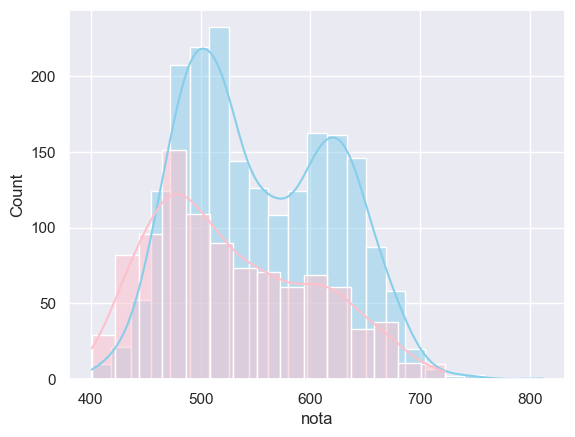

In [28]:
#gráficos 
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='darkgrid')

sns.histplot(df['nota'],color="skyblue", label="Real", kde=True)
sns.histplot(synthetic_df['nota'],color="pink", label="Sintético", kde=True)

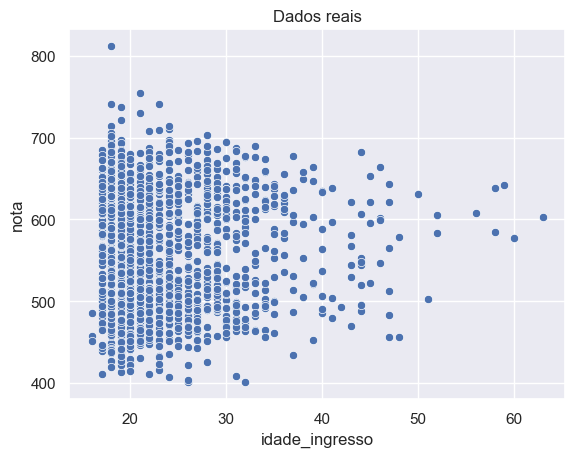

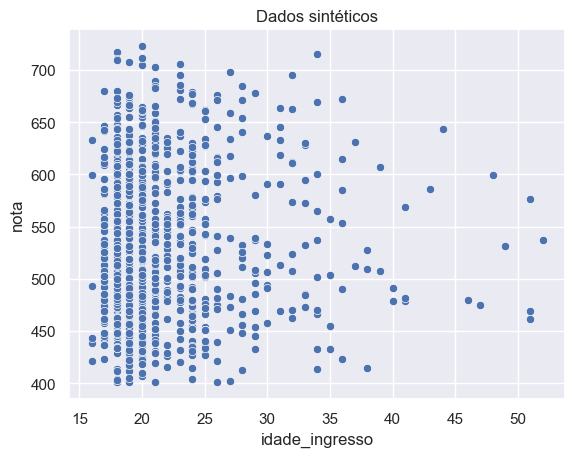

In [29]:
sns.scatterplot(data=df, x="idade_ingresso", y="nota")
plt.title("Dados reais")
plt.show()

sns.scatterplot(data=synthetic_df, x="idade_ingresso", y="nota")
plt.title("Dados sintéticos")
plt.show()